In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("archive/vgsales.csv")
print(df.shape)
print(df.head())
print(df.info())

(16598, 11)
   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
-

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
print(missing)

Year            271
Publisher        58
Rank              0
Platform          0
Name              0
Genre             0
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


In [5]:
df["Publisher"] = df["Publisher"].fillna("Unknown")
df = df.dropna(subset=["Year"])

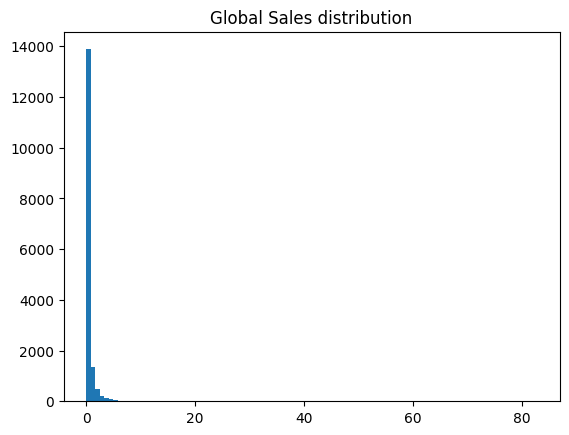

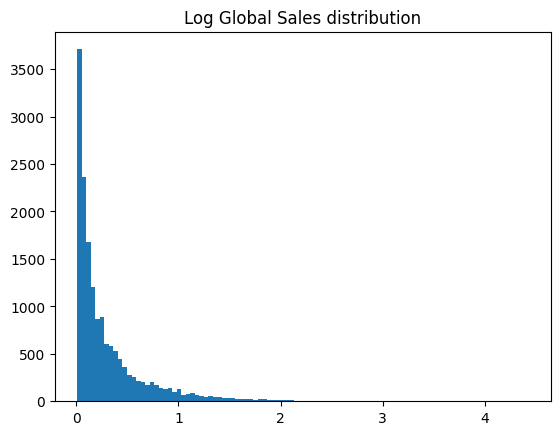

In [6]:
plt.hist(df["Global_Sales"], bins=100)
plt.title("Global Sales distribution")
plt.show()
plt.hist(np.log1p(df["Global_Sales"]), bins=100)
plt.title("Log Global Sales distribution")
plt.show()


In [7]:
df["Year"] = df["Year"].astype(int)
df["Decade"] = (df["Year"] // 10) * 10

df["Share_USA"] = df["NA_Sales"] / (df["Global_Sales"] + 1e-9)
df["Share_EU"] = df["EU_Sales"] / (df["Global_Sales"] + 1e-9)
df["Share_JP"] = df["JP_Sales"] / (df["Global_Sales"] + 1e-9)


In [8]:
platform_strength = df.groupby("Platform")["Global_Sales"].mean()
df["Platform_Strength"] = df["Platform"].map(platform_strength)

publisher_strength = df.groupby("Publisher")["Global_Sales"].mean()
df["Publisher_Strength"] = df["Publisher"].map(publisher_strength)

In [9]:
features = [
"Year", "Decade", "Platform_Strength", "Publisher_Strength"
]
X = df[features]
y = np.log1p(df["Global_Sales"])

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

cat_features = ["Platform", "Genre"]
num_features = features

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features)
    ]
)
X_all = df[cat_features + num_features]

X_train, X_test, y_train, y_test = train_test_split( X_all, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.linear_model import LinearRegression
model_lr = Pipeline([
    ("prep", preprocess),
    ("model", LinearRegression())
])
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)
rmse_lr = root_mean_squared_error(y_test, y_pred)
print("RMSE LR:", rmse_lr)


RMSE LR: 0.3542100188521149


In [ ]:
from sklearn.ensemble import RandomForestRegressor
model_rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
    ))
])
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)
rmse_rf = root_mean_squared_error(y_test, y_pred)
print("RMSE RF:", rmse_rf)

RMSE RF: 0.36412326748899915


In [16]:
from sklearn.ensemble import GradientBoostingRegressor
model_gb = Pipeline([
    ("prep", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

model_gb.fit(X_train, y_train)
y_pred = model_gb.predict(X_test)
rmse_gb = root_mean_squared_error(y_test, y_pred)
print("RMSE GB:", rmse_gb)


RMSE GB: 0.34563937796227123


In [17]:
rf_model = model_rf.named_steps["model"]
importances = rf_model.feature_importances_
feature_names = model_rf.named_steps["prep"].get_feature_names_out()
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)
print(imp_df.head(20))

                    feature  importance
46  num__Publisher_Strength    0.387221
43                num__Year    0.254308
45   num__Platform_Strength    0.098616
31        cat__Genre_Action    0.021972
38  cat__Genre_Role-Playing    0.019113
35      cat__Genre_Platform    0.018090
39       cat__Genre_Shooter    0.017861
44              num__Decade    0.017051
34          cat__Genre_Misc    0.015589
41        cat__Genre_Sports    0.015250
37        cat__Genre_Racing    0.014928
33      cat__Genre_Fighting    0.011177
40    cat__Genre_Simulation    0.010059
26        cat__Platform_Wii    0.008788
17        cat__Platform_PS3    0.008722
36        cat__Genre_Puzzle    0.008373
32     cat__Genre_Adventure    0.008027
42      cat__Genre_Strategy    0.007788
28       cat__Platform_X360    0.006260
16        cat__Platform_PS2    0.005622


In [18]:
df["Hit"] = (df["Global_Sales"] > 1.0).astype(int)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

y_cls = df["Hit"]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_cls, test_size=0.2, random_state=42
)

model_cls = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

model_cls.fit(X_train, y_train)
y_prob = model_cls.predict_proba(X_test)[:, 1]
print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.798110661268556


d:\sickens\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
